# Rare disease variants → AnnData

Protein localization for missense variants in HeLa cells ([`cpg0026`](https://broadinstitute.github.io/cellpainting-gallery/)). Published as `population_profiles` rather than `profiles`, and it carries localization calls and transfection efficiency alongside the morphology, so the obs are unusually rich. This notebook takes the cancer mutations batch.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*.csv.gz" \
  s3://cellpainting-gallery/cpg0026-lacoste_haghighi-rare-diseases/broad/workspace/population_profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0026-lacoste_haghighi-rare-diseases/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
print(f"{len(files)} plates")

10 plates


In [3]:
adata = cpio.read_profiles(files, path_columns={"batch": 2}, on_column_mismatch="intersect")
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:31: DtypeWarning: Columns (0: Metadata_transfection) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


/home/lheumos/code/cell-painting-io/cell_painting_io.py:31: DtypeWarning: Columns (0: Loc 2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)
/home/lheumos/code/cell-painting-io/cell_painting_io.py:31: DtypeWarning: Columns (0: Loc 5, 1: Metadata_transfection) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


/home/lheumos/code/cell-painting-io/cell_painting_io.py:31: DtypeWarning: Columns (0: Metadata_transfection) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 5634 × 1881
    obs: 'Plate', 'Well', 'AbsPositionZ', 'BinningX', 'BinningY', 'ChannelID', 'Col', 'ExposureTime', 'FieldID', 'ImageResolutionX', 'ImageResolutionY', 'ImageSizeX', 'ImageSizeY', 'MainEmissionWavelength', 'MainExcitationWavelength', 'MaxIntensity', 'ObjectiveMagnification', 'ObjectiveNA', 'PositionX', 'PositionY', 'PositionZ', 'Row', 'Site', 'Sample', 'Location', 'Notes', 'Efficiency', 'Loc 1', 'Loc 2', 'Loc 3', 'Loc 4', 'Loc 5', 'batch', 'Gene', 'Class', 'transfection', 'batch_Plate', 'Sample_Unique', 'Variant', 'normalization', 'zscored'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


for column in present(["Plate", "Class", "transfection", "Efficiency", "Loc 3", "normalization"]):
    adata.obs[column] = adata.obs[column].astype("category")
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
transfection_status,transfection,status,NaN,NaN,0
ImageNumber,imagenumber,,NaN,NaN,0
ObjectNumber,objectnumber,,NaN,NaN,0
Cells_AreaShape_Area,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_X,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Threshold_WeightedVariance_Cells,threshold,weightedvariance,NaN,NaN,0
Threshold_WeightedVariance_Nuclei,threshold,weightedvariance,NaN,NaN,0
n_transf,n,transf,NaN,NaN,0


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Class", "transfection", "Efficiency"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

5,634 wells x 1,795 features
non-finite: 0 | max|x|: 508792.2

Class:
Class
Mutant       3964
Wild-type    1494
NaN           176

transfection:
transfection
False    3990
True     1468
<NA>      176

Efficiency:
Efficiency
NaN         1644
low         1390
high        1170
med         1020
very low     410


In [6]:
adata.write_h5ad(PROFILES.parent / "rare_diseases.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "Class", "transfection", "Loc 3"]))

,observed,baseline,ratio
covariate,,,
Plate,0.425,0.100,4.239
Class,0.645,0.602,1.070
transfection,0.689,0.607,1.135
Loc 3,0.554,0.106,5.224


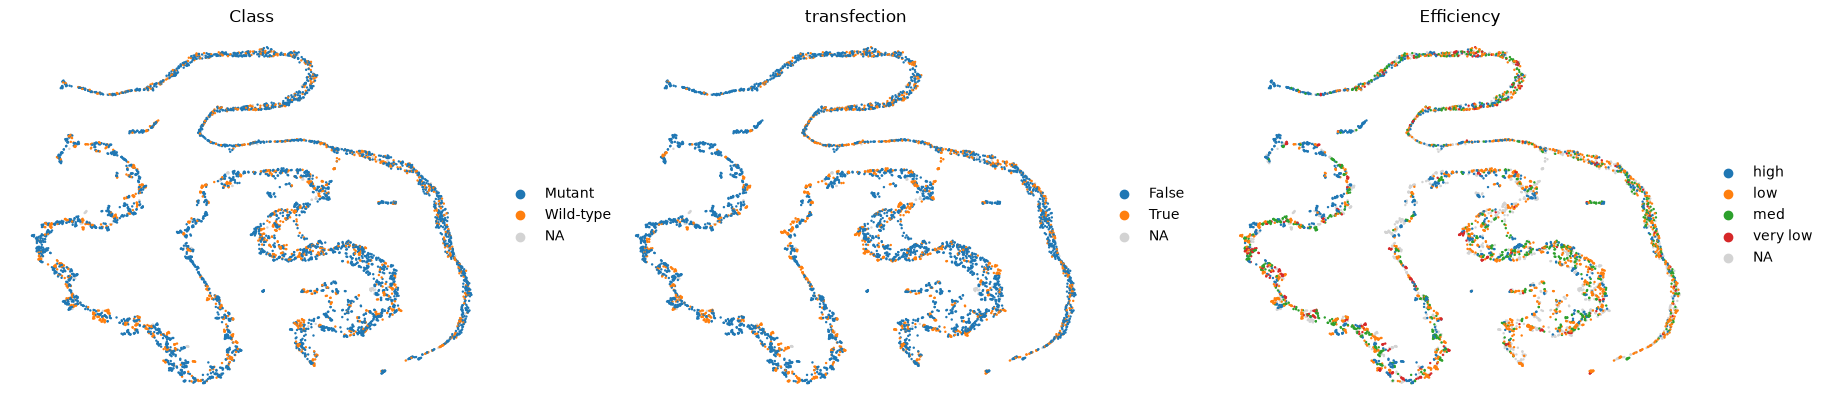

In [9]:
sc.pl.umap(adata, color=present(["Class", "transfection", "Efficiency", "Plate"])[:3], ncols=3, frameon=False, size=12)